   Year  Apple_Revenue  Google_Revenue  Samsung_Revenue
0  2019         260174          161857           197693
1  2020         274515          182527           200734
2  2021         365817          257637           244160
3  2022         394328          282836           211867
4  2023         383285          307394           201005
5  2024         391035          328284           209000


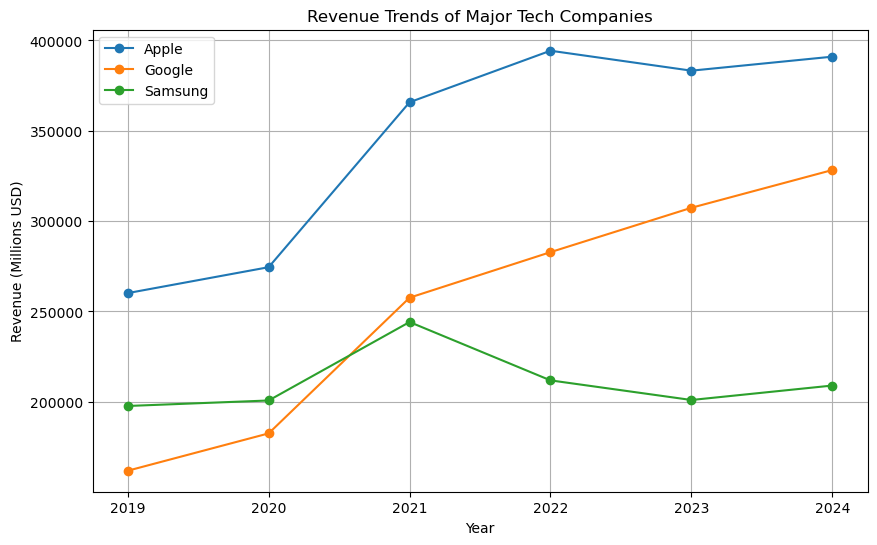

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv("../data/company_revenue.csv")

print(df)

# Plot revenue trends
plt.figure(figsize=(10,6))

plt.plot(df["Year"], df["Apple_Revenue"], marker="o", label="Apple")
plt.plot(df["Year"], df["Google_Revenue"], marker="o", label="Google")
plt.plot(df["Year"], df["Samsung_Revenue"], marker="o", label="Samsung")

plt.title("Revenue Trends of Major Tech Companies")
plt.xlabel("Year")
plt.ylabel("Revenue (Millions USD)")
plt.legend()
plt.grid(True)

plt.show()

In [2]:
# Forecast Google's revenue using linear regression

X = df[["Year"]]
y = df["Google_Revenue"]

model = LinearRegression()
model.fit(X, y)

future_years = pd.DataFrame({"Year": [2025, 2026, 2027]})
predictions = model.predict(future_years)

forecast_df = pd.DataFrame({
    "Year": future_years["Year"],
    "Projected_Google_Revenue": predictions
})

print(forecast_df)

   Year  Projected_Google_Revenue
0  2025             376616.000000
1  2026             411814.142857
2  2027             447012.285714


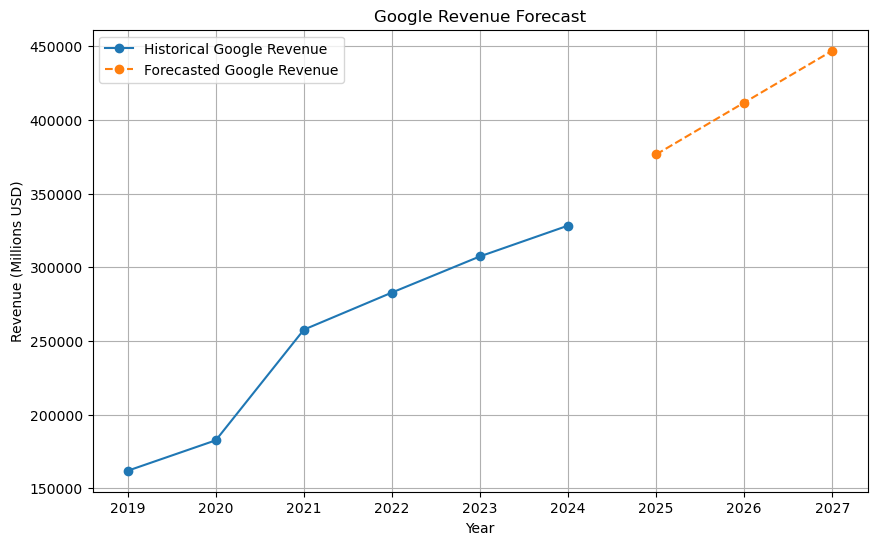

In [4]:
# Plot historical and forecasted Google revenue

plt.figure(figsize=(10,6))

plt.plot(df["Year"], df["Google_Revenue"], marker="o", label="Historical Google Revenue")
plt.plot(forecast_df["Year"], forecast_df["Projected_Google_Revenue"], marker="o", linestyle="--", label="Forecasted Google Revenue")

plt.title("Google Revenue Forecast")
plt.xlabel("Year")
plt.ylabel("Revenue (Millions USD)")
plt.legend()
plt.grid(True)

plt.savefig("revenue_chart.png", bbox_inches="tight")
plt.show()

In [5]:
# Calculate year-over-year revenue growth for Google

df["Google_Growth_%"] = df["Google_Revenue"].pct_change() * 100

print(df[["Year", "Google_Revenue", "Google_Growth_%"]])

   Year  Google_Revenue  Google_Growth_%
0  2019          161857              NaN
1  2020          182527        12.770532
2  2021          257637        41.150076
3  2022          282836         9.780816
4  2023          307394         8.682770
5  2024          328284         6.795839


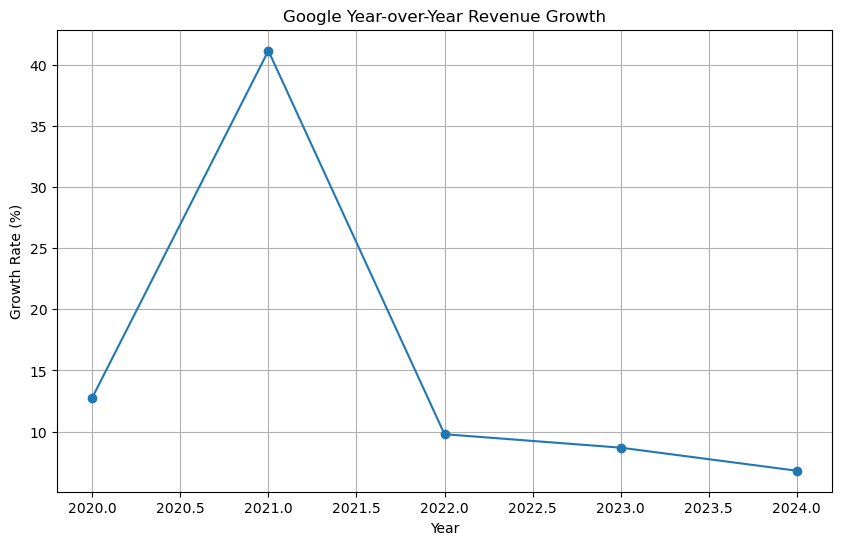

In [6]:
# Plot Google's revenue growth rate

plt.figure(figsize=(10,6))

plt.plot(df["Year"], df["Google_Growth_%"], marker="o")

plt.title("Google Year-over-Year Revenue Growth")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")

plt.grid(True)

plt.show()

In [7]:
# Calculate a 2-year moving average for Google revenue

df["Google_MA_2"] = df["Google_Revenue"].rolling(window=2).mean()

print(df[["Year", "Google_Revenue", "Google_MA_2"]])

   Year  Google_Revenue  Google_MA_2
0  2019          161857          NaN
1  2020          182527     172192.0
2  2021          257637     220082.0
3  2022          282836     270236.5
4  2023          307394     295115.0
5  2024          328284     317839.0


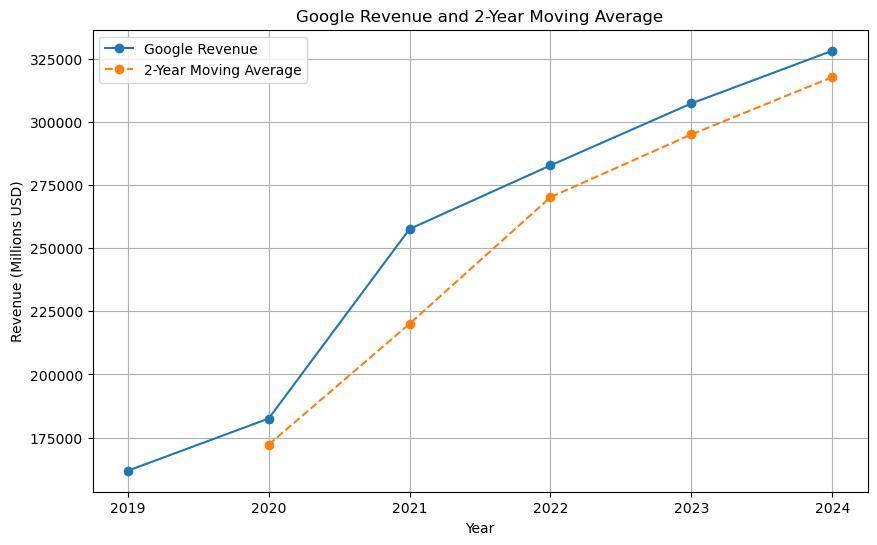

In [8]:
# Plot Google revenue with moving average

plt.figure(figsize=(10,6))

plt.plot(df["Year"], df["Google_Revenue"], marker="o", label="Google Revenue")
plt.plot(df["Year"], df["Google_MA_2"], marker="o", linestyle="--", label="2-Year Moving Average")

plt.title("Google Revenue and 2-Year Moving Average")
plt.xlabel("Year")
plt.ylabel("Revenue (Millions USD)")
plt.legend()
plt.grid(True)

plt.show()